In [30]:
import sys
import os

# Get the absolute path of the project root
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [32]:
import yfinance as yf
import logging
import os
import warnings

# --- Disable Streamlit internal logs before it initializes ---
os.environ["STREAMLIT_SUPPRESS_LOGS"] = "1"
os.environ["STREAMLIT_LOGGING_LEVEL"] = "ERROR"

# Configure Streamlit logging more comprehensively
logging.getLogger(
    "streamlit.runtime.caching.cache_data_api").setLevel(logging.ERROR)
logging.getLogger("streamlit").setLevel(logging.ERROR)
logging.getLogger("streamlit.runtime.connection").setLevel(logging.ERROR)
logging.getLogger("streamlit.runtime").setLevel(logging.ERROR)
logging.getLogger("streamlit.elements").setLevel(logging.ERROR)

# Disable all existing loggers
logging.disable(logging.WARNING)

# --- Suppress Python warnings ---
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="No runtime found")
warnings.filterwarnings("ignore", message=".*auto_adjust.*")
warnings.filterwarnings("ignore", message="YF.download()")

# Also suppress the download progress output
# Suppress the progress bar by monkey-patching tqdm if needed
try:
    from tqdm import tqdm
    tqdm._instances.clear()
except:
    pass

In [33]:

import numpy as np
import pandas as pd
import streamlit as st
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from data.data_loader import load_data

In [8]:
# df = load_data('BTC-USD')
from pandas import read_csv

In [9]:
print(os.getcwd())

c:\Users\parth\OneDrive - Southampton Solent University\COM724 - Assessment(AI)\notebooks


In [10]:


df = read_csv('../data/BTC-USD/BTC-USD_from_2010-01-01_till_2026-01-01.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


## Understand The Dataset

In [11]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [14]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616


In [13]:
df.shape

(4124, 5)

In [12]:
# Set Date as index for time series analysis

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4124 entries, 2014-09-17 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4124 non-null   float64
 1   High    4124 non-null   float64
 2   Low     4124 non-null   float64
 3   Open    4124 non-null   float64
 4   Volume  4124 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 193.3 KB


In [15]:
df.describe()

,Close,High,Low,Open,Volume
count,4124.000000,4124.000000,4124.000000,4124.000000,4.124000e+03
mean,26848.337164,27368.668781,26257.635395,26828.253857,2.163072e+10
std,31650.548142,32181.993148,31062.425775,31639.828872,2.288509e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,2701.332458,2771.027527,2613.842590,2690.982544,1.286307e+09
50%,10765.186035,11022.057617,10442.993164,10762.840820,1.708105e+10
75%,42236.827148,43017.266602,41396.099609,42200.933594,3.317551e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


## Data Cleaning

In [18]:
df.isna().sum() # Check for missing values

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [19]:
df.ffill(inplace=True)  # Filling the missing values with Forward fill method

In [20]:
df.duplicated().sum()  # Check for duplicate rows

np.int64(0)

In [21]:
df.drop_duplicates(inplace=True)  # Remove duplicate rows if any

## Univariate Analysis

In [27]:
df.describe()

,Close,High,Low,Open,Volume
count,4124.000000,4124.000000,4124.000000,4124.000000,4.124000e+03
mean,26848.337164,27368.668781,26257.635395,26828.253857,2.163072e+10
std,31650.548142,32181.993148,31062.425775,31639.828872,2.288509e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,2701.332458,2771.027527,2613.842590,2690.982544,1.286307e+09
50%,10765.186035,11022.057617,10442.993164,10762.840820,1.708105e+10
75%,42236.827148,43017.266602,41396.099609,42200.933594,3.317551e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


### Checking the normality

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

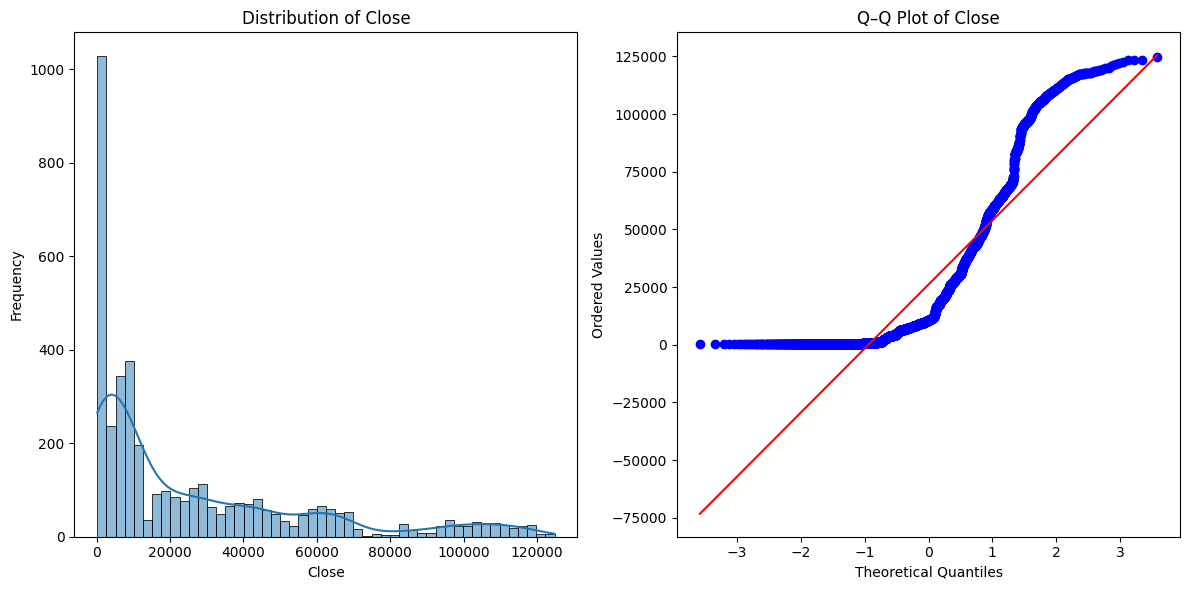

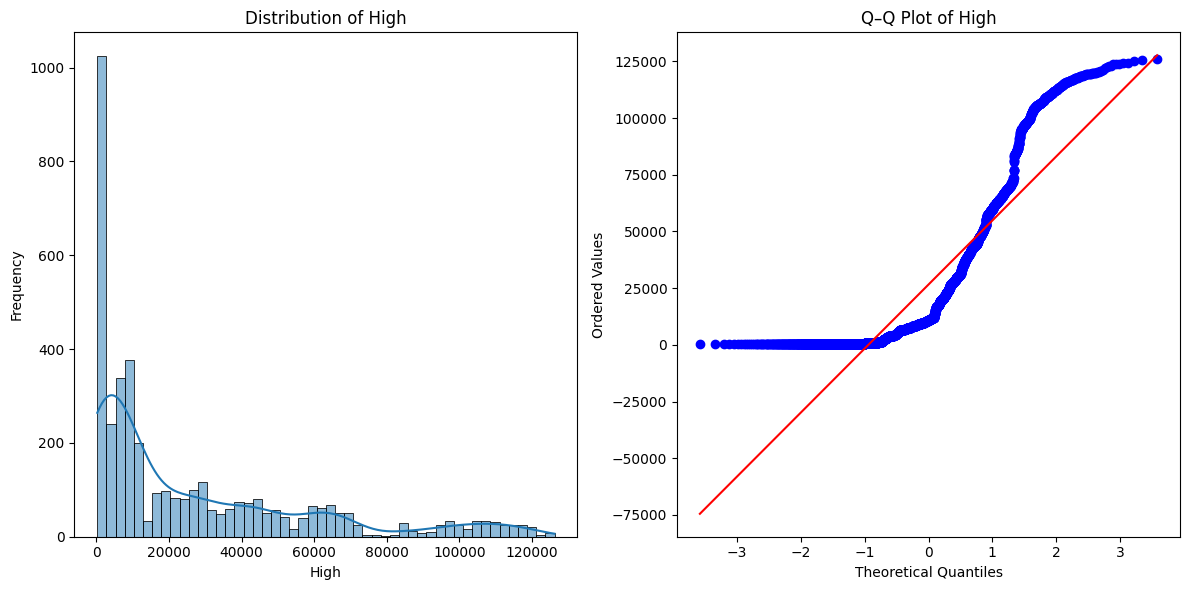

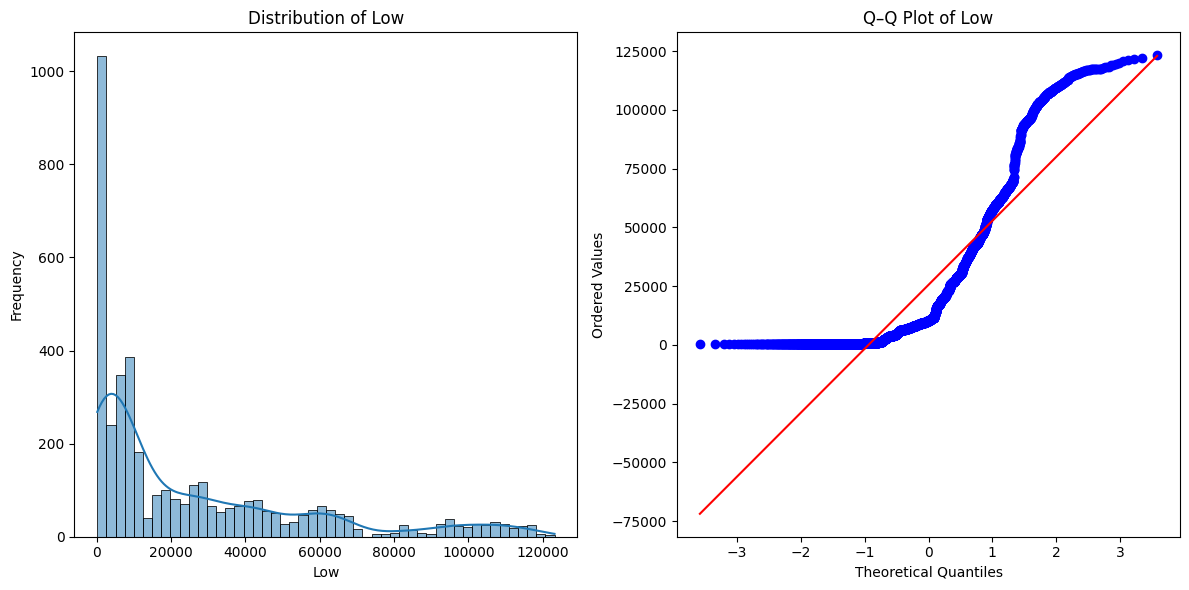

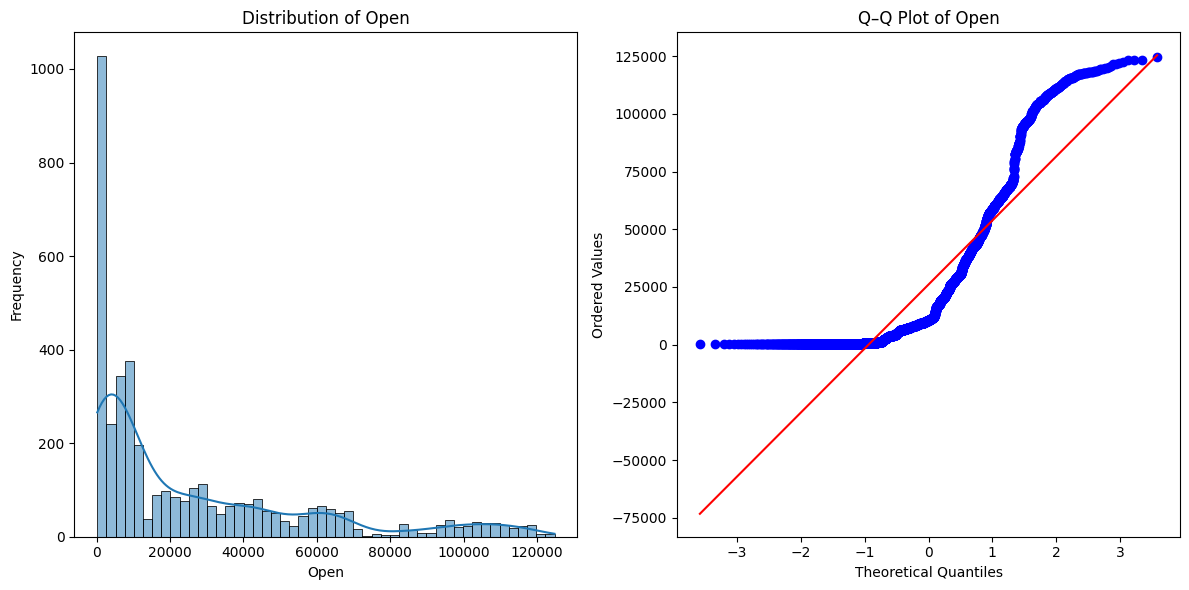

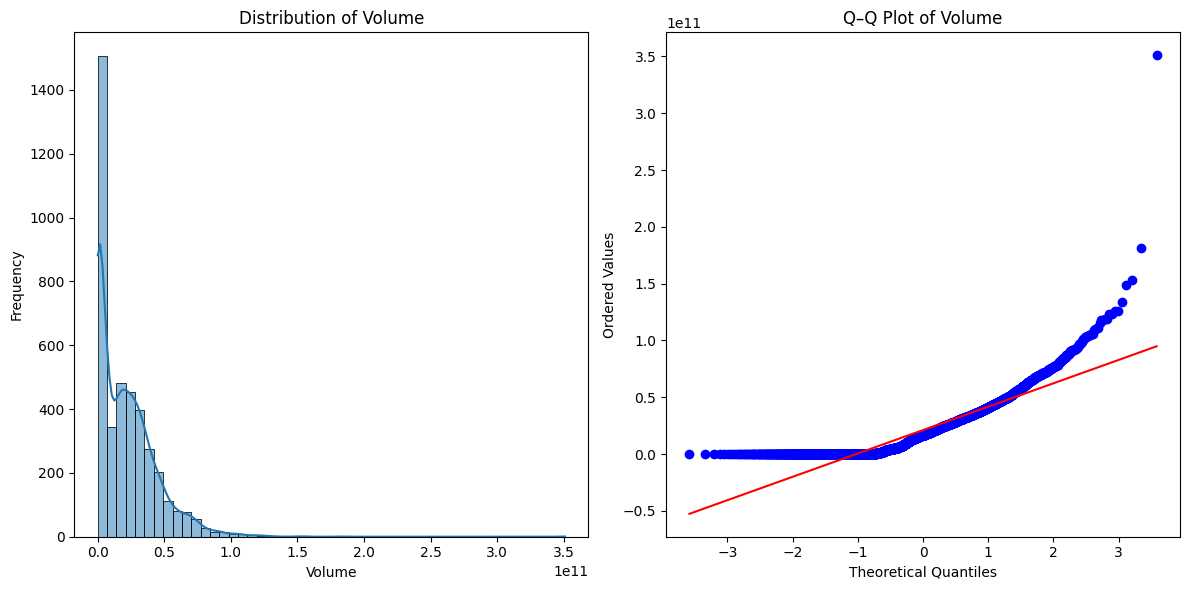

In [17]:
# Applying QQPlot and Histogram to check normality

%matplotlib inline

# Loop through all numeric columns in the DataFrame
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    # Create subplots: one row, two columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left: Histogram with KDE ---
    sns.histplot(df[col], kde=True, bins=50, ax=ax1)
    ax1.set_title(f'Distribution of {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')

    # --- Right: Q–Q Plot ---
    stats.probplot(df[col].dropna(), dist="norm", plot=ax2)
    ax2.set_title(f"Q–Q Plot of {col}")
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Ordered Values')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.preprocessing import (
    FunctionTransformer, PowerTransformer,
    StandardScaler, MinMaxScaler, RobustScaler
)

In [19]:
df_new = df.copy()  # Create a copy of the original DataFrame

In [20]:
transformations = {
    'Log': FunctionTransformer(np.log1p),
    'Sqrt': FunctionTransformer(np.sqrt),
    'Cbrt': FunctionTransformer(np.cbrt),
    'Reciprocal': FunctionTransformer(lambda x: 1 / (x + 1e-9)),
    # Yeo-Johnson works with zero/negative values
    'YeoJohnson': PowerTransformer(method='yeo-johnson'),
    # Box-Cox requires all positive data
    'BoxCox': PowerTransformer(method='box-cox'),
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

# Apply transformations to every numeric column
for col in df_new.select_dtypes(include=['float64', 'int64']).columns:
    for name, transformer in transformations.items():
        try:
            # Box-Cox requires strictly positive values
            if name == 'BoxCox' and (df_new[col] <= 0).any():
                continue  # Skip if column has zero or negative values

            df_new[f'{col}_{name}'] = transformer.fit_transform(df_new[[col]])

        except Exception as e:
            print(f"⚠️ Skipping {col}_{name} due to error: {e}")

In [21]:
df_new.head()

,Close,High,Low,Open,Volume,Close_Log,Close_Sqrt,Close_Cbrt,Close_Reciprocal,Close_YeoJohnson,...,Open_Robust,Volume_Log,Volume_Sqrt,Volume_Cbrt,Volume_Reciprocal,Volume_YeoJohnson,Volume_BoxCox,Volume_Standard,Volume_MinMax,Volume_Robust
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,6.127598,21.385369,7.704501,0.002187,-1.418620,...,-0.261575,16.862734,4588.768898,276.140935,4.749060e-08,-1.623048,-1.623048,-0.941331,0.000043,-0.534373
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,6.053124,20.601942,7.515169,0.002356,-1.442795,...,-0.261809,17.355983,5872.239777,325.488653,2.899963e-08,-1.572630,-1.572630,-0.940734,0.000081,-0.533946
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,5.980899,19.869474,7.335971,0.002533,-1.465931,...,-0.262662,17.450981,6157.897368,335.960561,2.637152e-08,-1.562075,-1.562075,-0.940582,0.000091,-0.533837
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,6.015923,20.221375,7.422333,0.002446,-1.454750,...,-0.263427,17.422735,6071.540167,332.812208,2.712703e-08,-1.565244,-1.565244,-0.940628,0.000088,-0.533871
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,5.991017,19.970504,7.360817,0.002507,-1.462708,...,-0.263078,17.095673,5155.589200,298.436682,3.762213e-08,-1.600124,-1.600124,-0.941086,0.000059,-0.534198


In [22]:
df_new.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_BoxCox', 'Volume_Standard',
       'Volume_MinMax', 'Volume_Robust'],
      dtype='object')

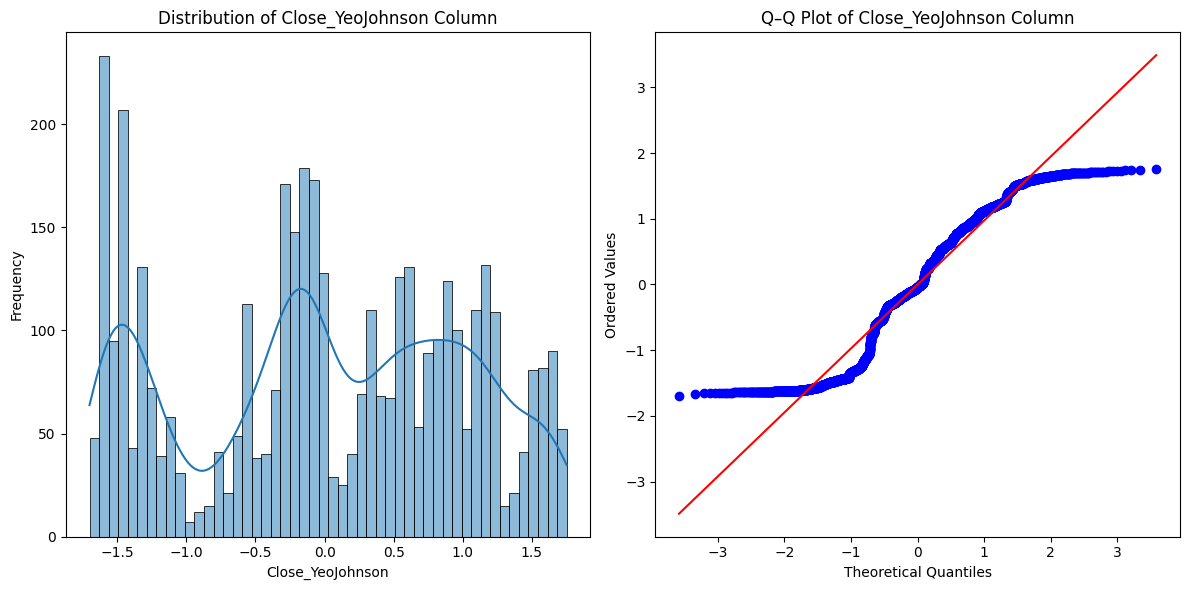

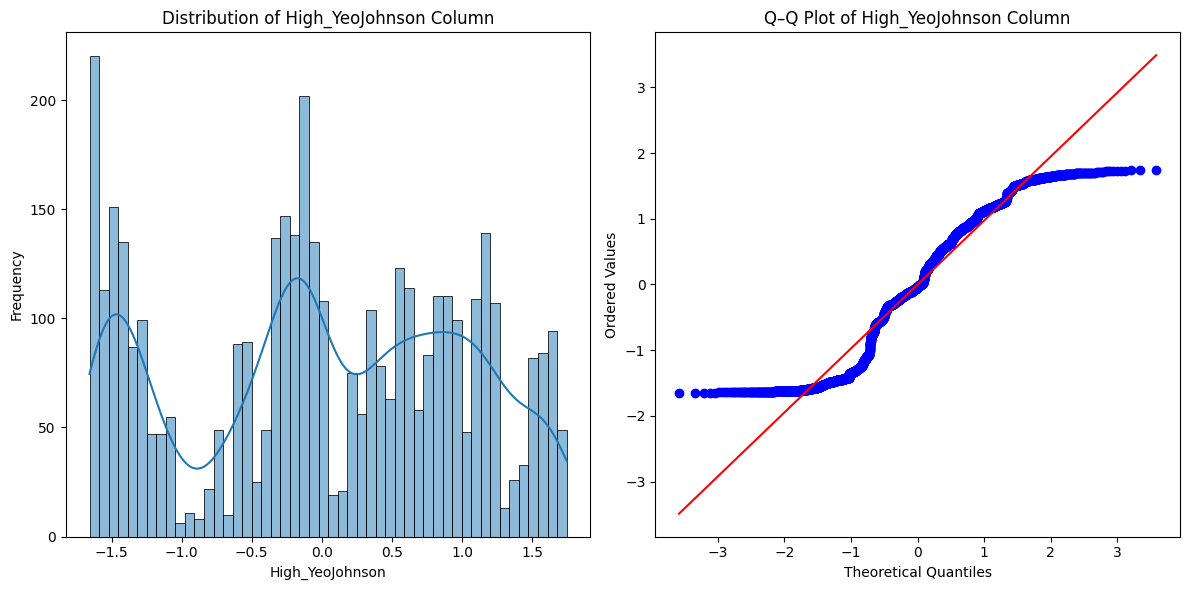

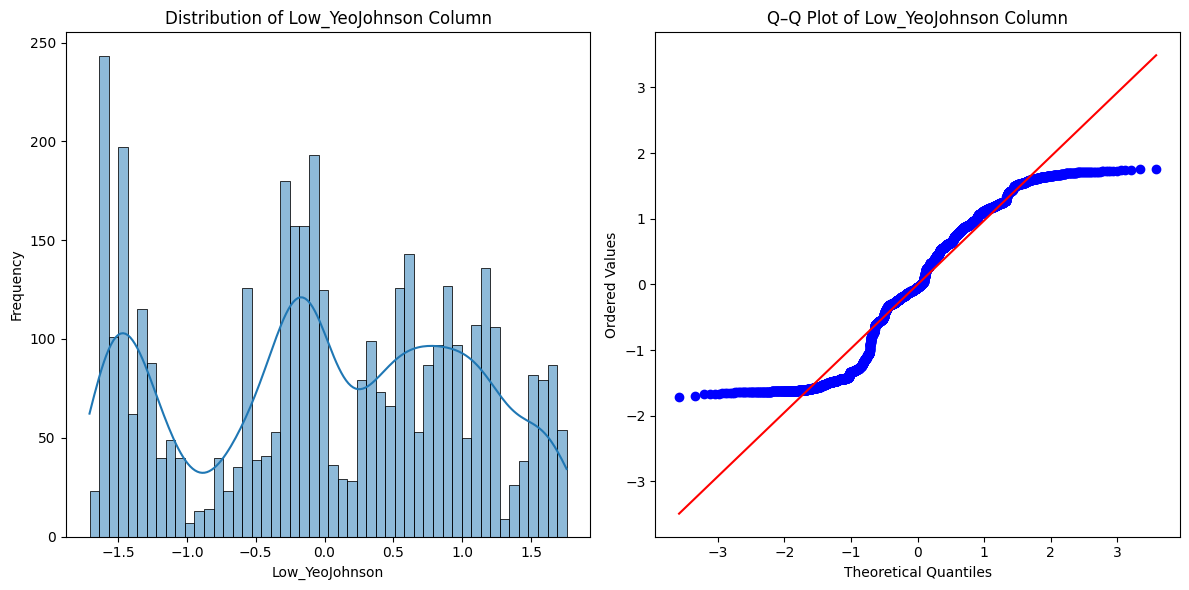

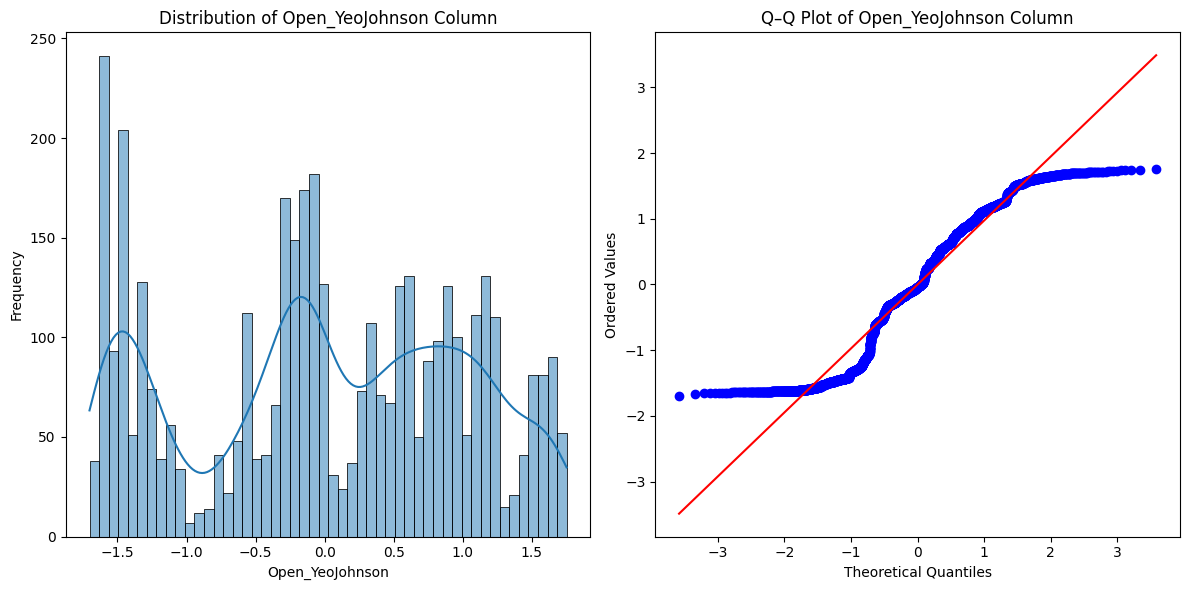

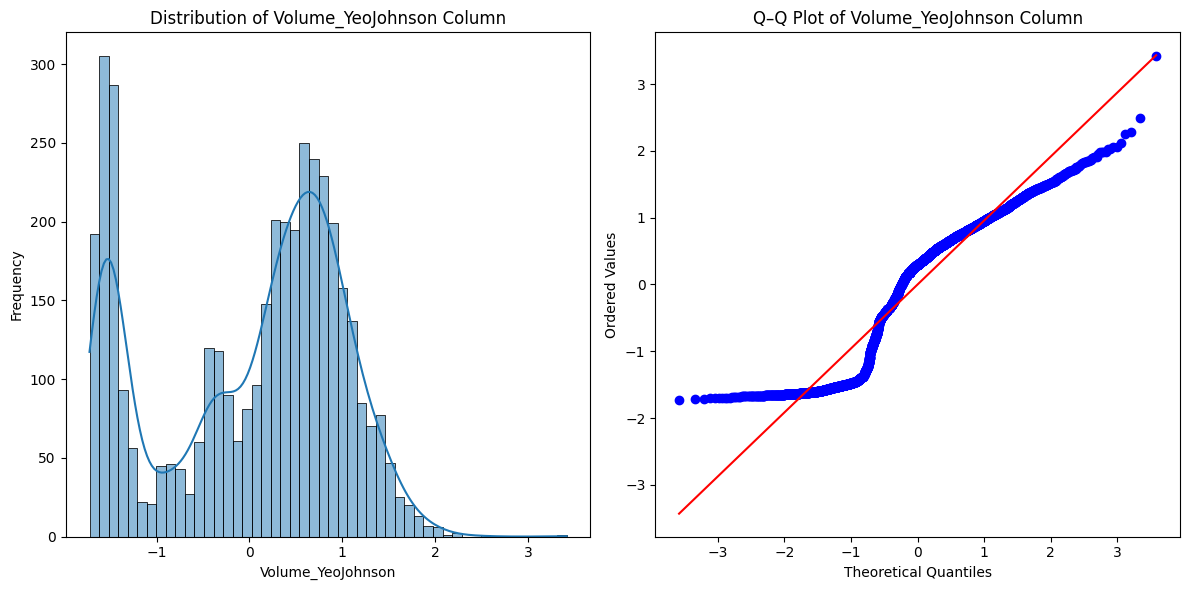

In [23]:
# Loop over all columns that end with '_YeoJohnson'
for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left: Histogram with KDE ---
    sns.histplot(df_new[col].dropna(), kde=True, bins=50, ax=ax1)
    ax1.set_title(f'Distribution of {col} Column')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')

    # --- Right: Q–Q Plot ---
    stats.probplot(df_new[col].dropna(), dist="norm", plot=ax2)
    ax2.set_title(f"Q–Q Plot of {col} Column")
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Ordered Values')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

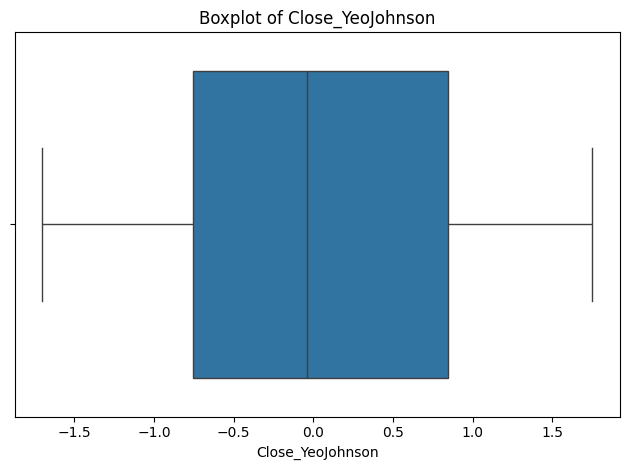

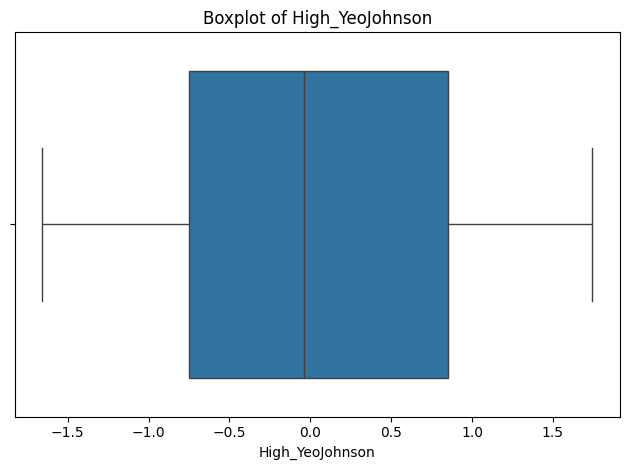

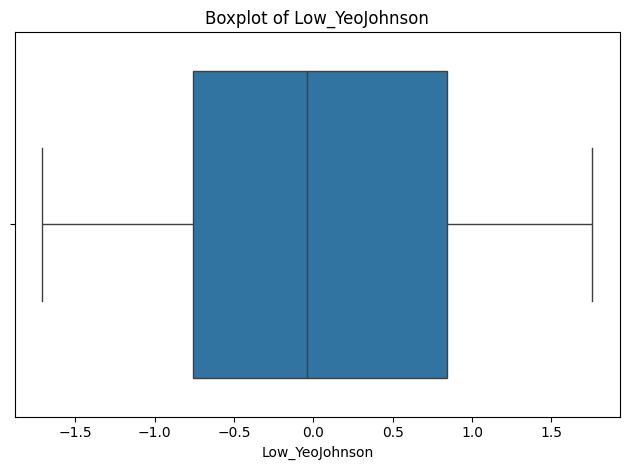

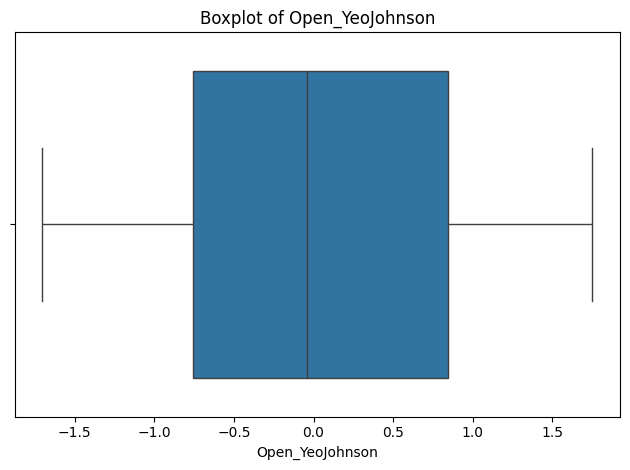

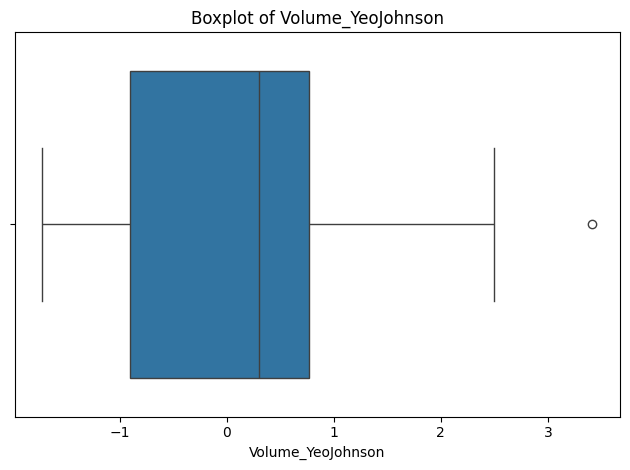

In [25]:
# Loop through all columns ending with '_YeoJohnson' to create boxplots
for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    sns.boxplot(x=df_new[col], orient='h')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

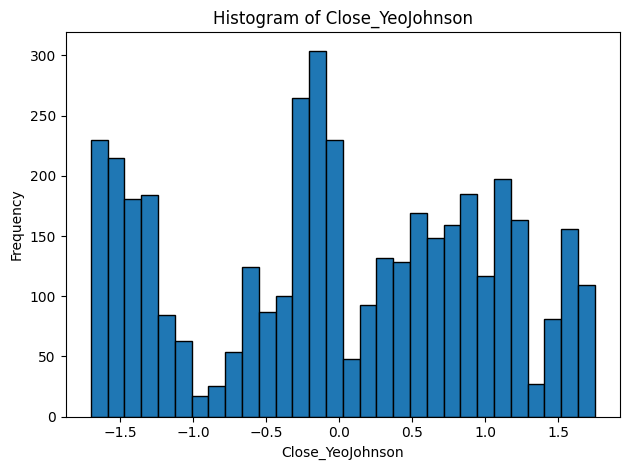

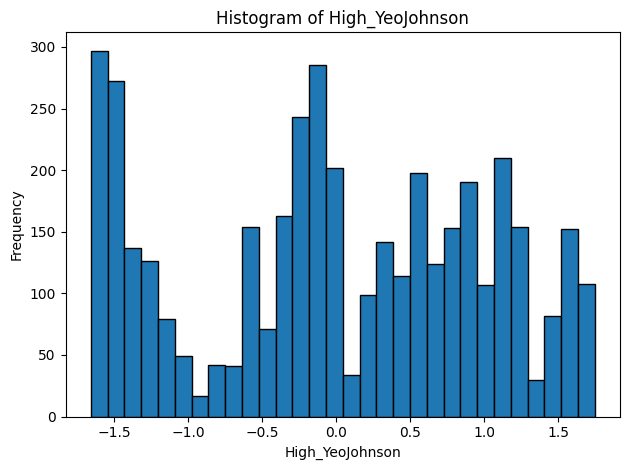

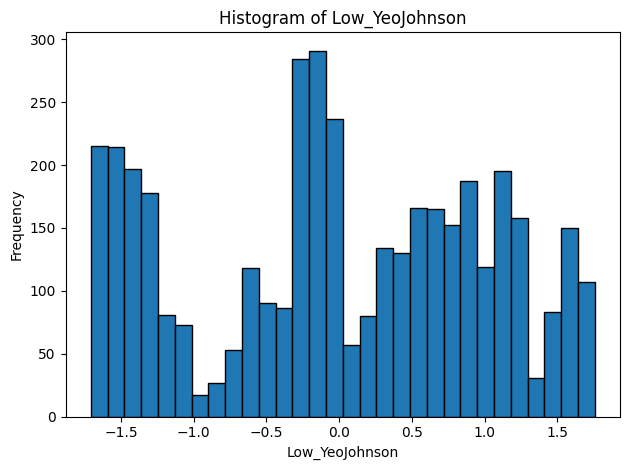

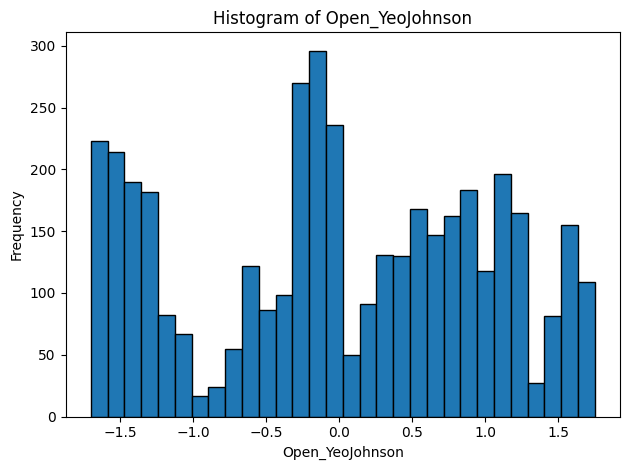

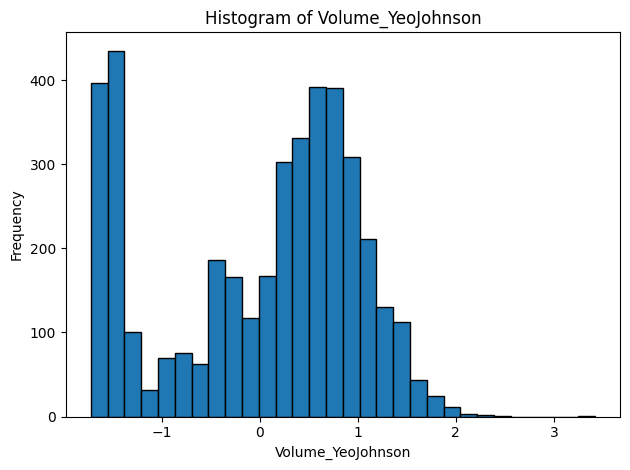

In [26]:
# Loop through all columns ending with '_YeoJohnson'  to create histograms
for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    plt.hist(df_new[col], bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Removing The Outliers

#### Trimming

In [27]:
df_new.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_BoxCox', 'Volume_Standard',
       'Volume_MinMax', 'Volume_Robust'],
      dtype='object')

In [28]:
upper_limit = df_new['Volume_YeoJohnson'].quantile(0.95)
upper_limit

1.3515972661449709

In [29]:
lower_limit = df_new['Volume_YeoJohnson'].quantile(0.05)
lower_limit

-1.6199327804053838

In [30]:
df_updated = df_new[(lower_limit <= df_new['Volume_YeoJohnson']) &
       (df_new['Volume_YeoJohnson'] <= upper_limit)]

In [31]:
df_updated.shape

(3667, 50)

In [32]:
df_new.shape

(4075, 50)

In [33]:
df_updated.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_BoxCox', 'Volume_Standard',
       'Volume_MinMax', 'Volume_Robust'],
      dtype='object')

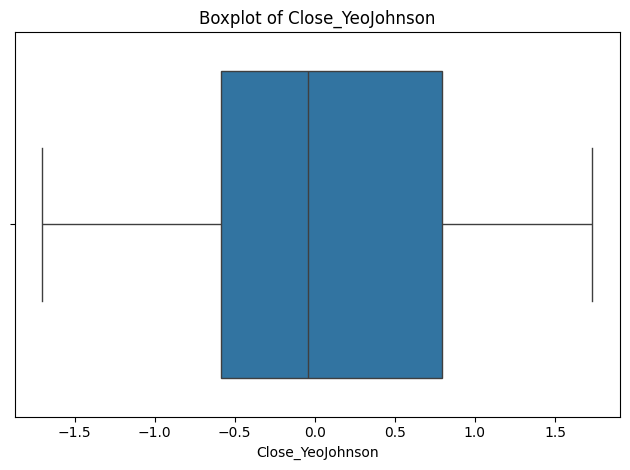

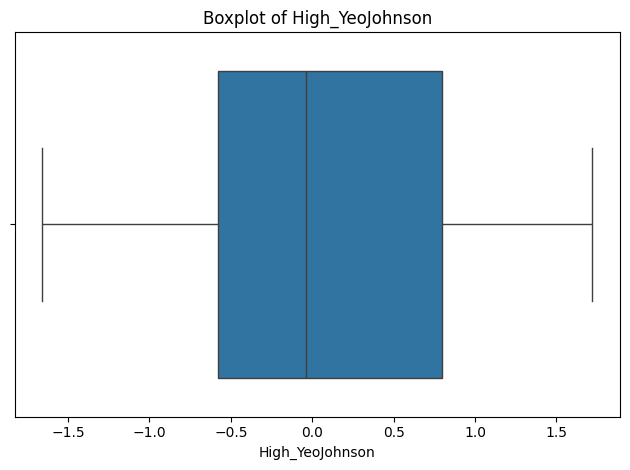

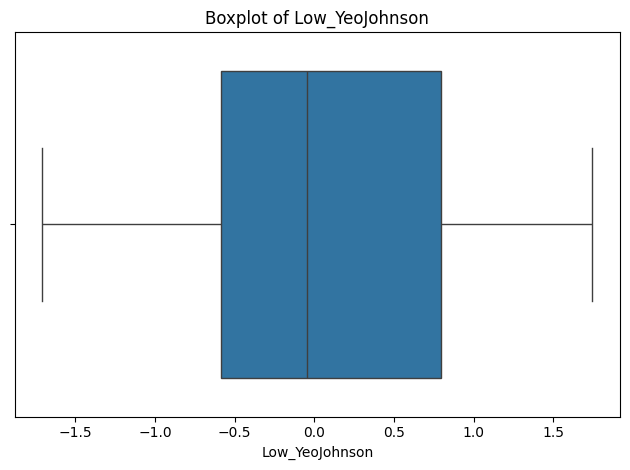

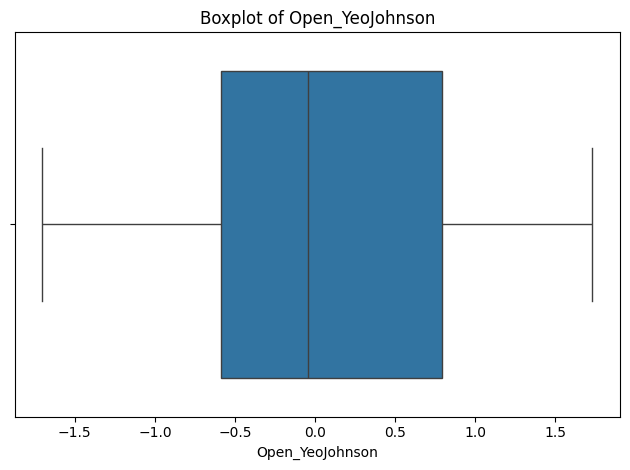

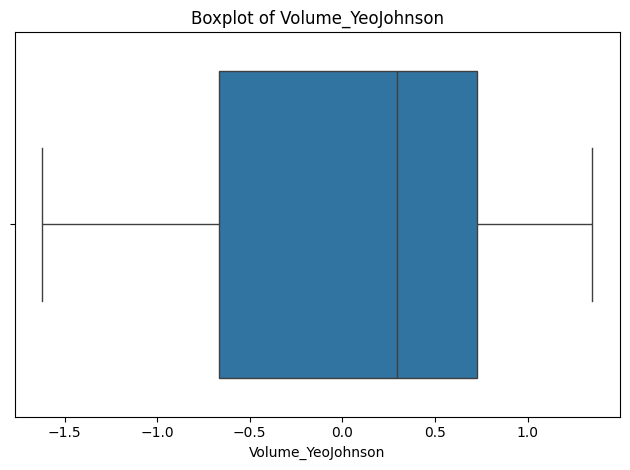

In [34]:
# Loop through all df_updated columns ending with '_YeoJohnson' to create boxplots
for col in [c for c in df_updated.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    sns.boxplot(x=df_updated[col], orient='h')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

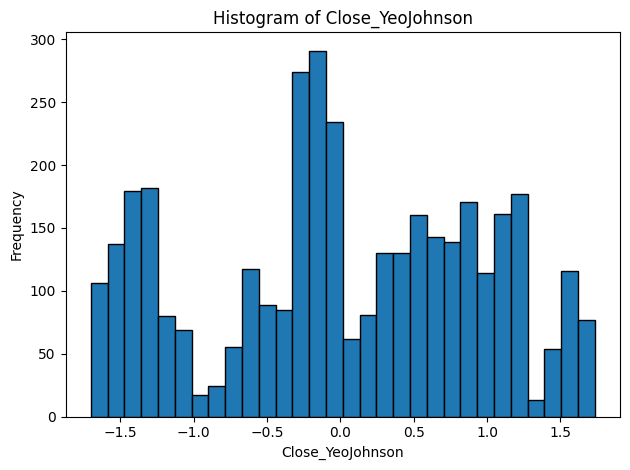

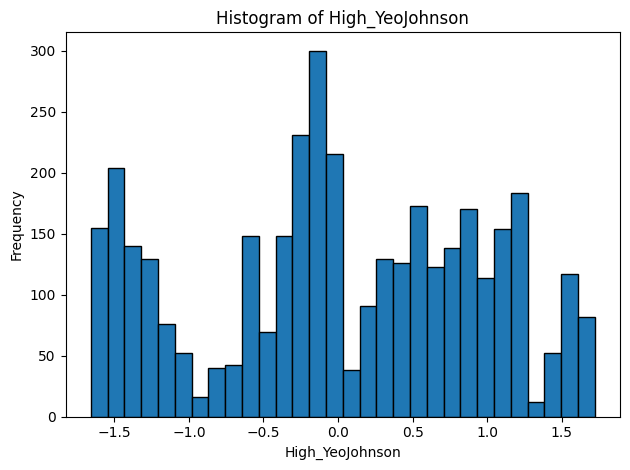

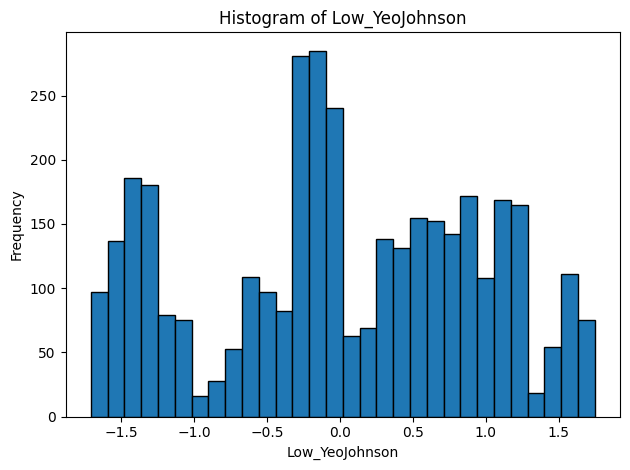

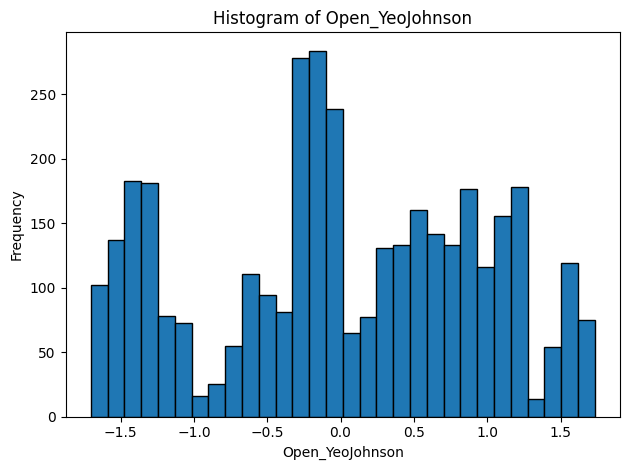

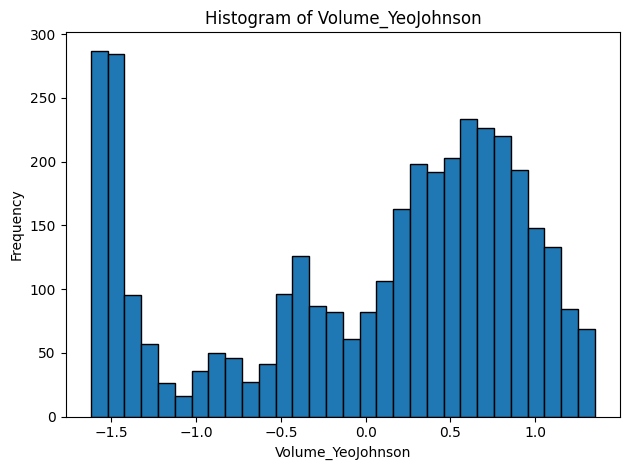

In [35]:
# Loop through all columns ending with '_YeoJohnson'
for col in [c for c in df_updated.columns if c.endswith('_YeoJohnson')]:
    plt.figure()
    plt.hist(df_updated[col], bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [36]:
df_updated.shape

(3667, 50)

#### Capping - Winsorization Method

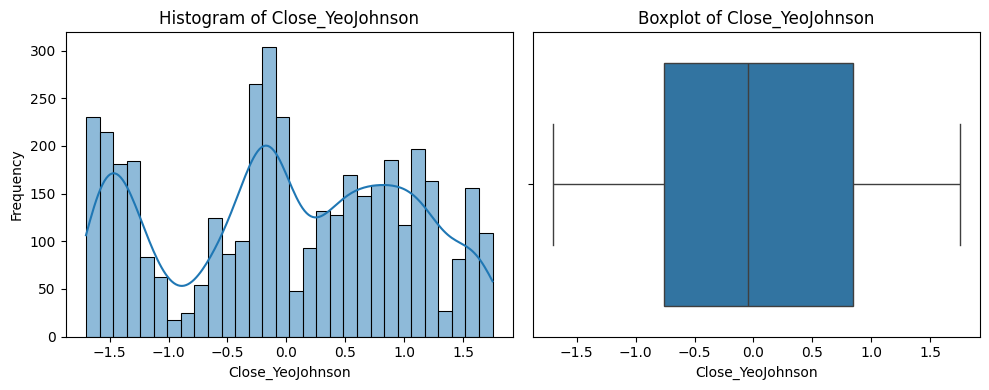

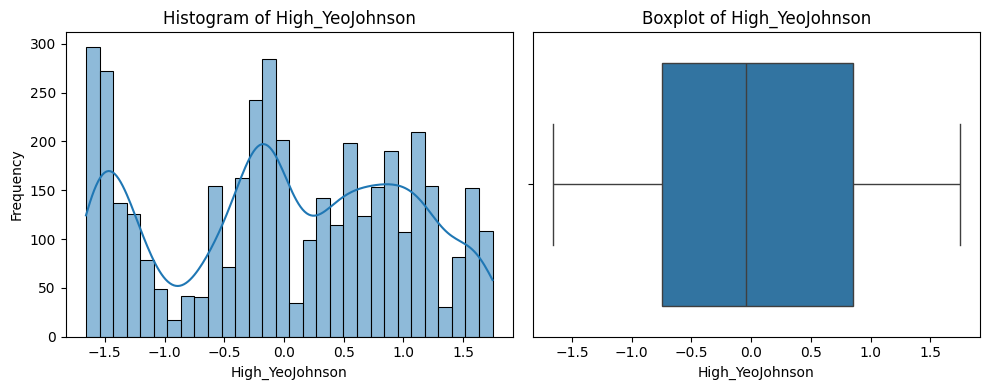

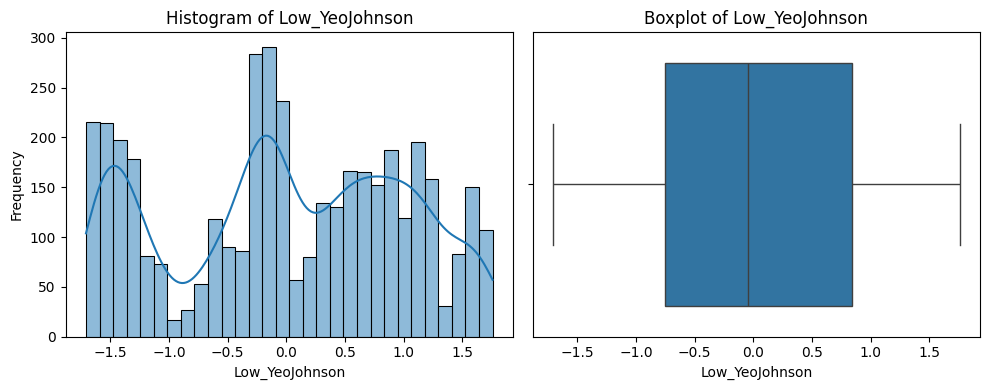

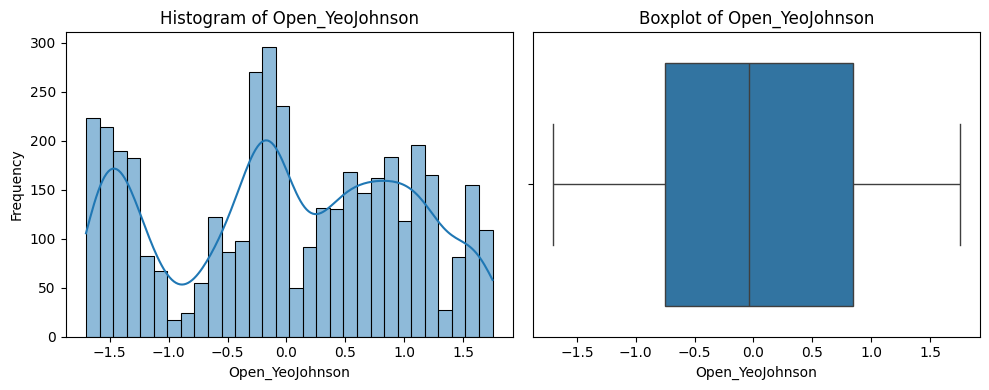

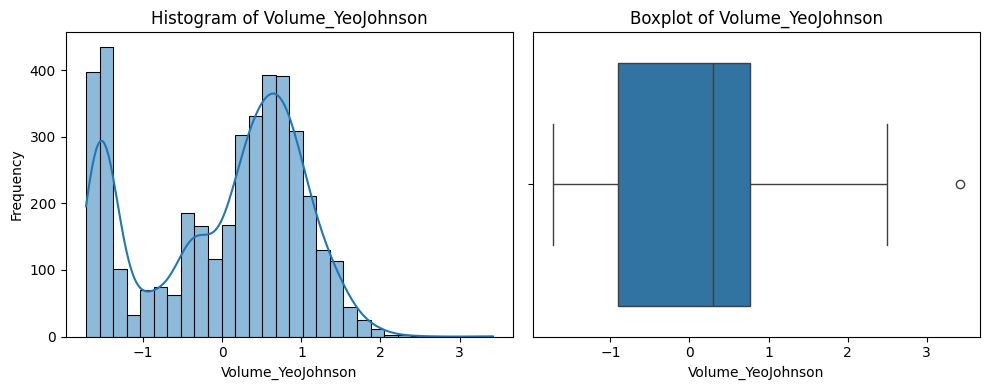

In [37]:

# Loop through all columns ending with '_YeoJohnson'
for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram (left side)
    sns.histplot(df_new[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Boxplot (right side)
    sns.boxplot(x=df_new[col], orient='h', ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [38]:
lower_limit = df_new['Volume_YeoJohnson'].quantile(0.05)
upper_limit = df_new['Volume_YeoJohnson'].quantile(0.95)

In [39]:
df_winsorized = df_new.copy()

In [40]:
df_winsorized['Volume_YeoJohnson'] = np.where(df_new['Volume_YeoJohnson'] <= lower_limit, 
      lower_limit, 
      np.where(df_new['Volume_YeoJohnson'] >= upper_limit,
      upper_limit,
      df_new['Volume_YeoJohnson']))

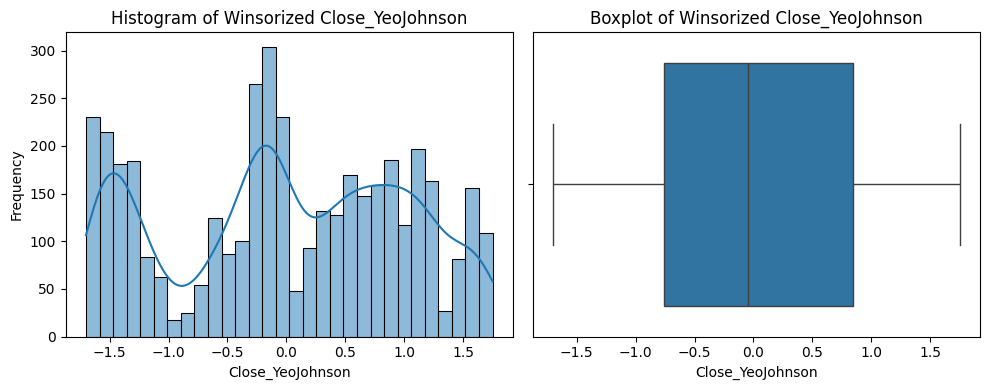

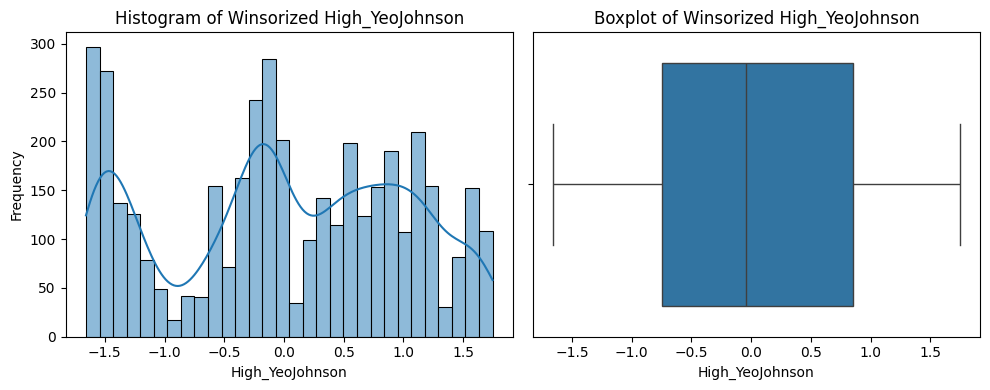

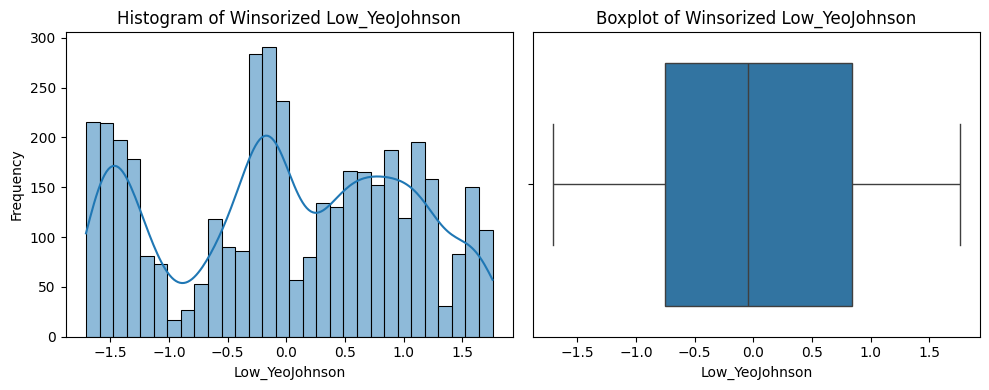

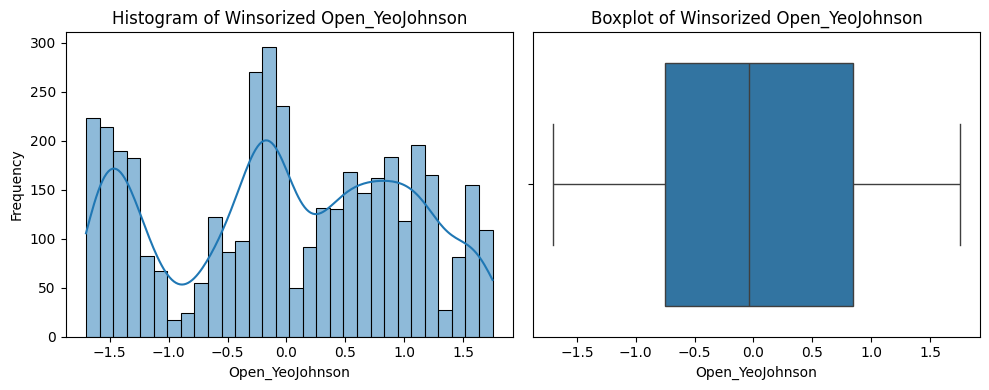

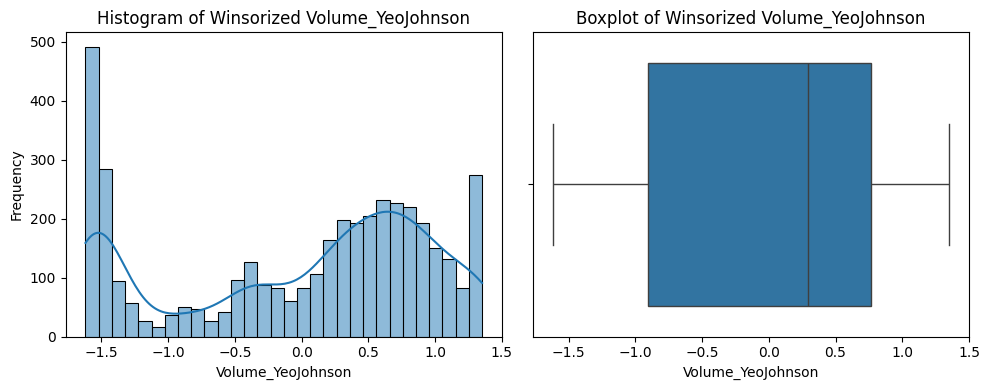

In [41]:
# Loop through all columns ending with '_YeoJohnson'
for col in [c for c in df_winsorized.columns if c.endswith('_YeoJohnson')]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram (left side)
    sns.histplot(df_winsorized[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of Winsorized {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Boxplot (right side)
    sns.boxplot(x=df_winsorized[col], orient='h', ax=axes[1])
    axes[1].set_title(f'Boxplot of Winsorized {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## Multivariate Analysis

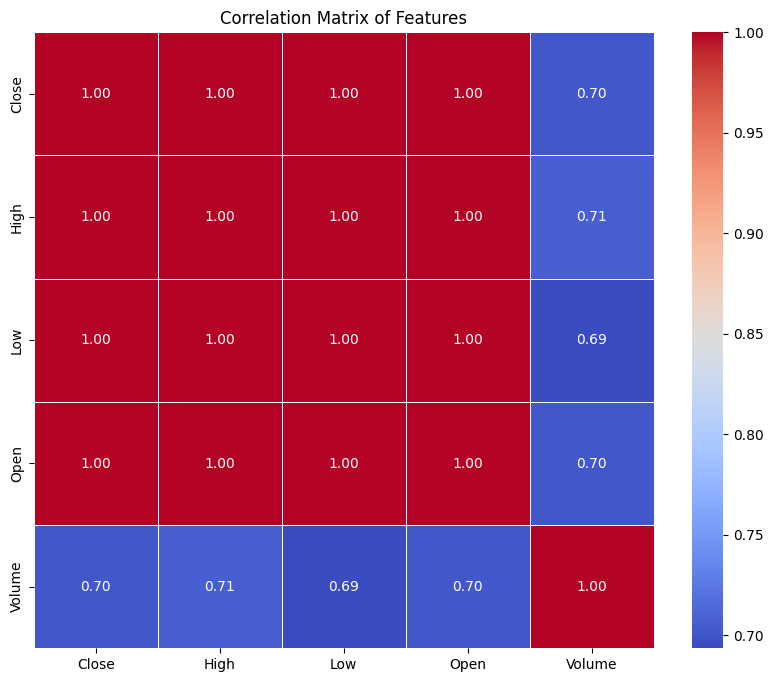

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# --- Correlation Matrix Explaination ---

# OHLC features (Open, High, Low, Close) show almost perfect correlation (~1.00) with each other

# If the market is up, all four go up.
# If the market is down, all four go down.
# When trading volume increases, price tends to be higher.

In [43]:
df_winsorized.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_BoxCox',
       'Close_Standard', 'Close_MinMax', 'Close_Robust', 'High_Log',
       'High_Sqrt', 'High_Cbrt', 'High_Reciprocal', 'High_YeoJohnson',
       'High_BoxCox', 'High_Standard', 'High_MinMax', 'High_Robust', 'Low_Log',
       'Low_Sqrt', 'Low_Cbrt', 'Low_Reciprocal', 'Low_YeoJohnson',
       'Low_BoxCox', 'Low_Standard', 'Low_MinMax', 'Low_Robust', 'Open_Log',
       'Open_Sqrt', 'Open_Cbrt', 'Open_Reciprocal', 'Open_YeoJohnson',
       'Open_BoxCox', 'Open_Standard', 'Open_MinMax', 'Open_Robust',
       'Volume_Log', 'Volume_Sqrt', 'Volume_Cbrt', 'Volume_Reciprocal',
       'Volume_YeoJohnson', 'Volume_BoxCox', 'Volume_Standard',
       'Volume_MinMax', 'Volume_Robust'],
      dtype='object')

In [44]:
df_winsorized = df_winsorized[[
    'Open_YeoJohnson', 'High_YeoJohnson', 'Low_YeoJohnson',
    'Close_YeoJohnson', 'Volume_YeoJohnson'
]]

df_winsorized.head()

,Open_YeoJohnson,High_YeoJohnson,Low_YeoJohnson,Close_YeoJohnson,Volume_YeoJohnson
Date,,,,,
2014-09-17,-1.412100,-1.417031,-1.415416,-1.418620,-1.619933
2014-09-18,-1.418478,-1.424974,-1.445007,-1.442795,-1.572630
2014-09-19,-1.442585,-1.446111,-1.467995,-1.465931,-1.562075
2014-09-20,-1.465580,-1.449521,-1.463586,-1.454750,-1.565244
2014-09-21,-1.454932,-1.457812,-1.460893,-1.462708,-1.600124


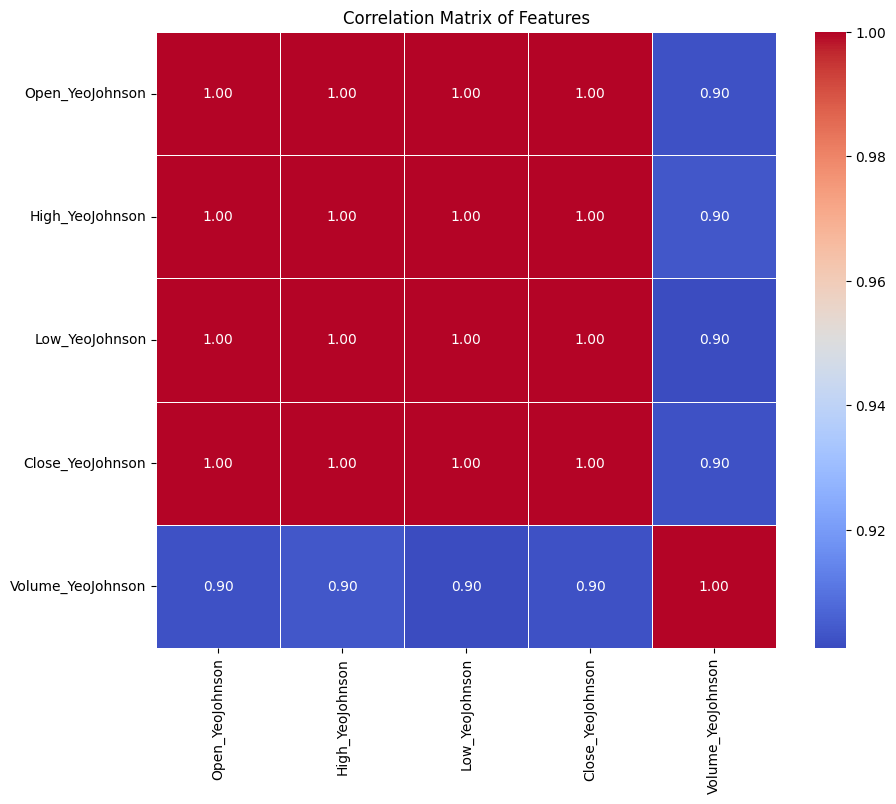

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_winsorized.corr(numeric_only=True), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

## Time Series Specific Checks

#### Trend Visualization

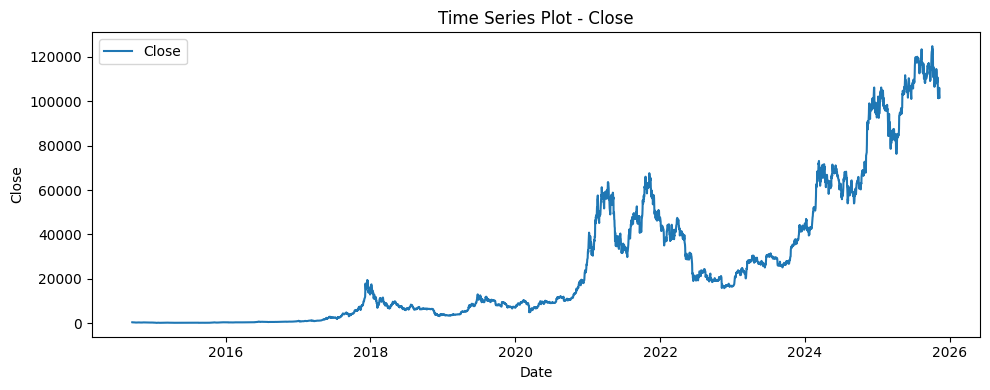

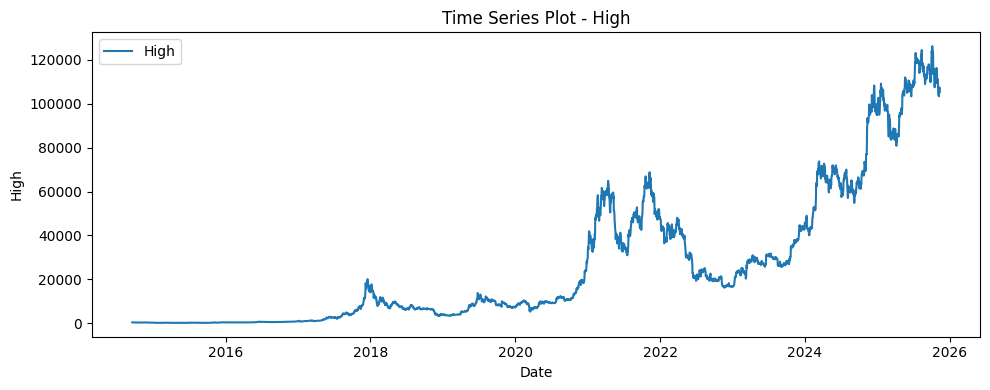

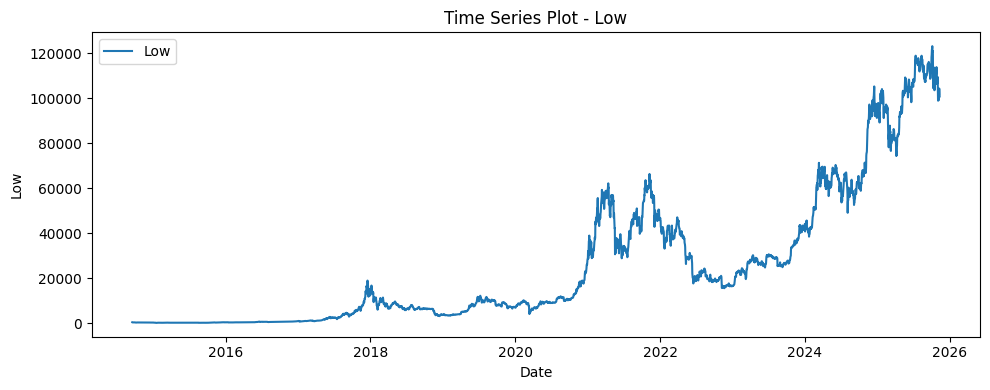

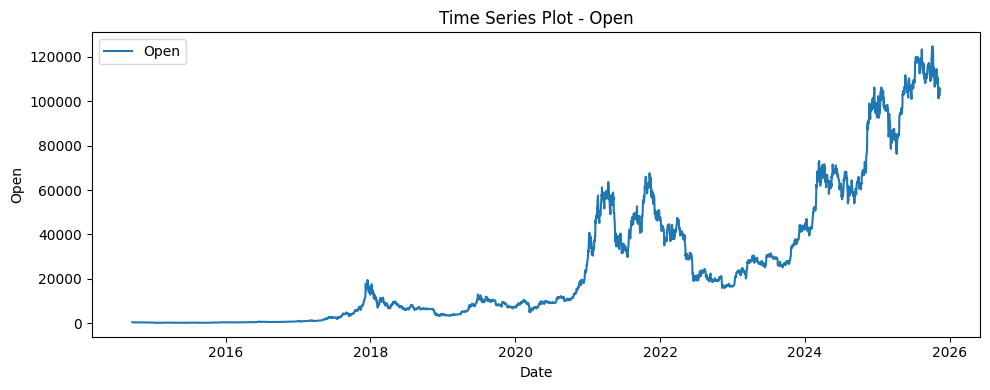

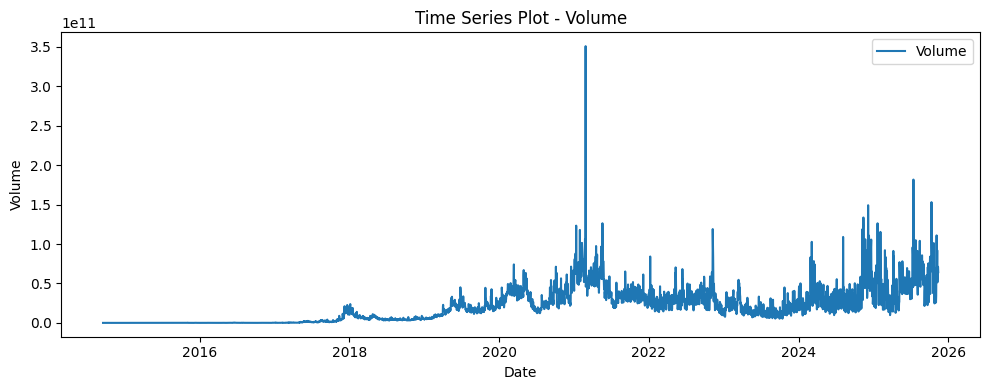

In [46]:
import matplotlib.pyplot as plt

# Plot each time series column
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df.index, df[col], label=col)
    plt.title(f'Time Series Plot - {col}')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

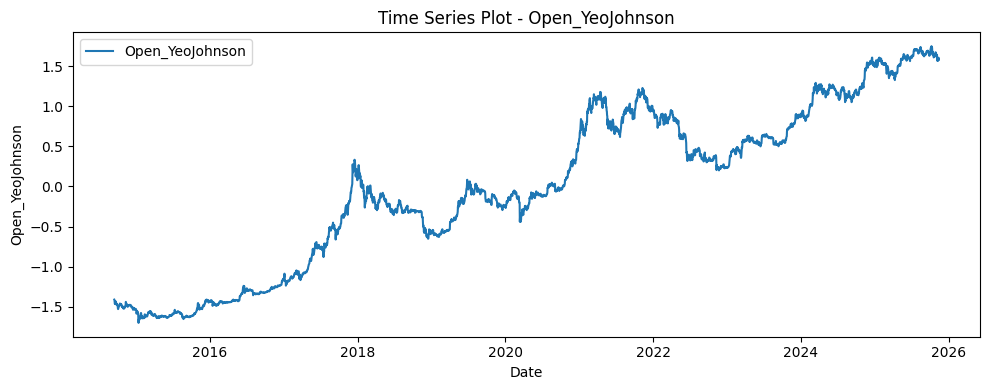

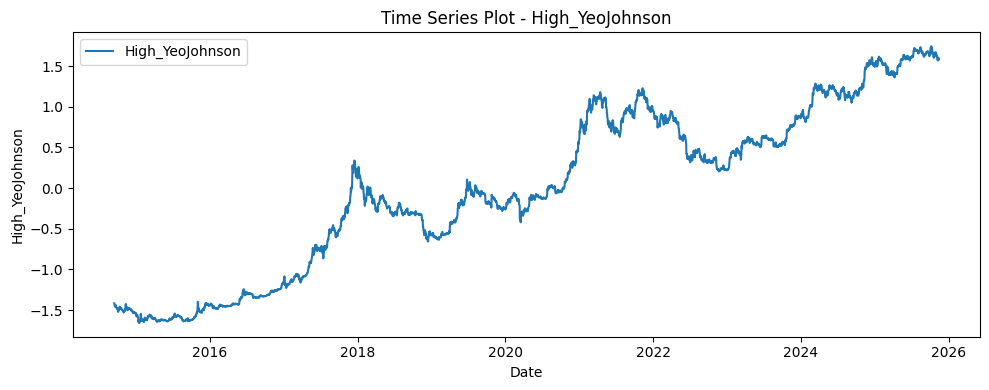

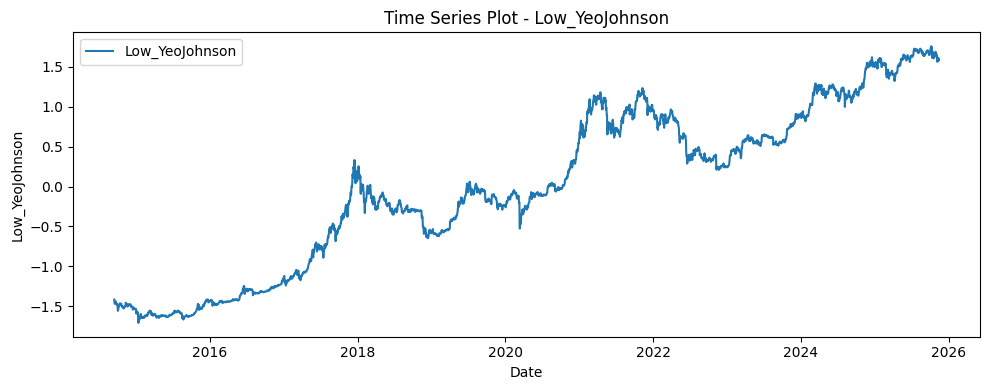

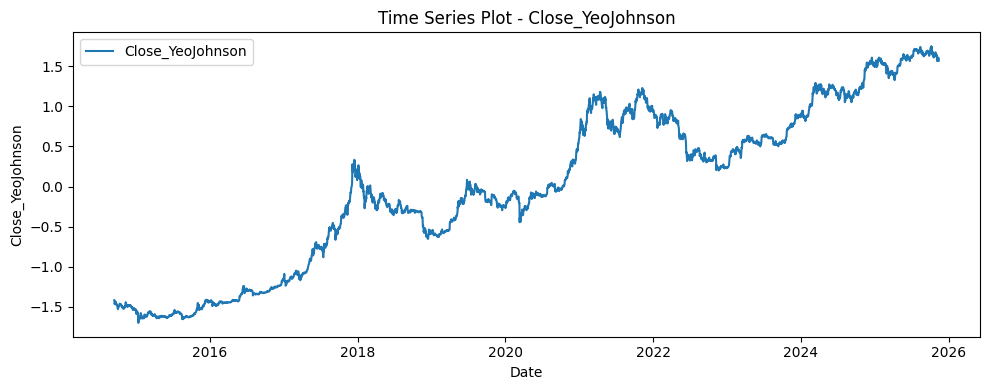

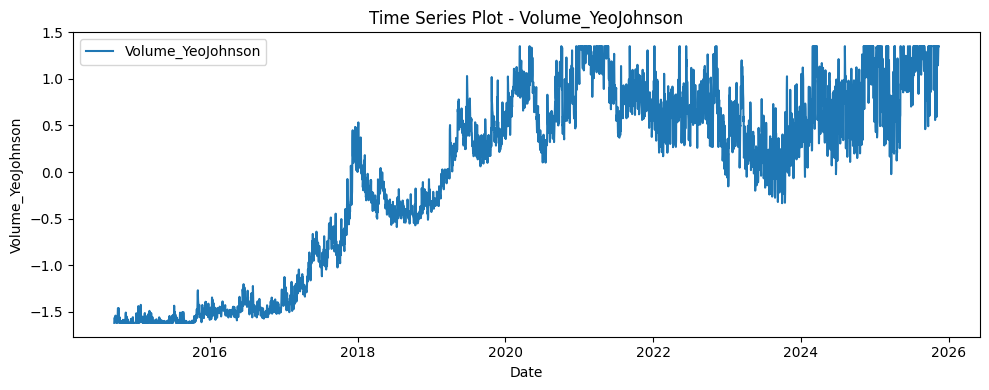

In [47]:
import matplotlib.pyplot as plt

# Plot each time series column
for col in df_winsorized.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df_winsorized.index, df_winsorized[col], label=col)
    plt.title(f'Time Series Plot - {col}')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Stationarity Check

In [48]:
# KPSS Test for Stationarity
from statsmodels.tsa.stattools import kpss

for col in df_winsorized.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\n================= KPSS Test for {col} =================")
    try:
        statistic, p_value, n_lags, critical_values = kpss(
            df_winsorized[col].dropna(), regression='c', nlags="auto")
        print(f"KPSS Statistic: {statistic}")
        print(f"p-value: {p_value}")
        print(f"Used lags: {n_lags}")
        # for key, value in critical_values.items():
        #     print(f"Critical Value ({key}): {value}")

        if p_value < 0.05:
            print("❌ The series is likely non-stationary (reject H₀).")
        else:
            print("✅ The series is likely stationary (fail to reject H₀).")
    except Exception as e:
        print(f"⚠️ Could not perform KPSS test on {col}: {e}")


================= KPSS Test for Open_YeoJohnson =================
KPSS Statistic: 9.28063181527321
p-value: 0.01
Used lags: 39
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for High_YeoJohnson =================
KPSS Statistic: 9.262646490584663
p-value: 0.01
Used lags: 39
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for Low_YeoJohnson =================
KPSS Statistic: 9.305563698117545
p-value: 0.01
Used lags: 39
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for Close_YeoJohnson =================
KPSS Statistic: 9.280391885779569
p-value: 0.01
Used lags: 39
❌ The series is likely non-stationary (reject H₀).

================= KPSS Test for Volume_YeoJohnson =================
KPSS Statistic: 8.27037802967055
p-value: 0.01
Used lags: 39
❌ The series is likely non-stationary (reject H₀).


C:\Users\parth\AppData\Local\Temp\ipykernel_28608\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_28608\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_28608\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_28608\1003007198.py:7: InterpolationWarning: The test statistic is outside of the range of p

In [49]:
# ADF Test for Stationarity
from statsmodels.tsa.stattools import adfuller

for col in df_winsorized.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\n================= ADF Test for {col} =================")
    result = adfuller(df_winsorized[col].dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    # for key, value in result[4].items():
    #     print(f"Critical Value ({key}): {value}")

    if result[1] <= 0.05:
        print("✅ The series is likely stationary (reject H₀).")
    else:
        print("❌ The series is likely non-stationary (fail to reject H₀).")


================= ADF Test for Open_YeoJohnson =================
ADF Statistic: -0.49912606272122206
p-value: 0.8921869267957478
❌ The series is likely non-stationary (fail to reject H₀).

================= ADF Test for High_YeoJohnson =================
ADF Statistic: -0.5454595714438749
p-value: 0.8828359704728741
❌ The series is likely non-stationary (fail to reject H₀).

================= ADF Test for Low_YeoJohnson =================
ADF Statistic: -0.6276940133030011
p-value: 0.8646007321825238
❌ The series is likely non-stationary (fail to reject H₀).

================= ADF Test for Close_YeoJohnson =================
ADF Statistic: -0.5403136517268016
p-value: 0.8839066035333576
❌ The series is likely non-stationary (fail to reject H₀).

================= ADF Test for Volume_YeoJohnson =================
ADF Statistic: -1.3336245008640204
p-value: 0.6136521648583638
❌ The series is likely non-stationary (fail to reject H₀).
